In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.metrics import f1_score, ConfusionMatrixDisplay
import cv2
import pandas as pd
import pickle
import os
from tensorflow.keras.callbacks import ModelCheckpoint

In [2]:
# Initialize empty lists to hold all data and labels
all_data = []
all_labels = []

def file_open(file_path):
    try:
        with open(file_path, 'rb') as f:
            data_dict = pickle.load(f, encoding='latin1')
            all_data.append(data_dict['data'])  # Append batch data
            all_labels.extend(data_dict['labels'])  # Extend labels
    except FileNotFoundError:
        print(f"File not found: {file_path}")
    except Exception as e:
        print(f"Error loading file {file_path}: {e}")

# Load all batches
base_path = r'.\Dataset\cifar-10-batches-py'
for i in range(1, 6):
    file_path = os.path.join(base_path, f"data_batch_{i}")
    file_open(file_path)

# Convert the list of arrays into a single numpy array
all_data = np.vstack(all_data)  # Stack all data arrays vertically
all_labels = np.array(all_labels)  # Convert labels to numpy array

print(f"Data shape: {all_data.shape}")  # Should be (50000, 3072)
print(f"Labels shape: {all_labels.shape}")  # Should be (50000,)


Data shape: (50000, 3072)
Labels shape: (50000,)


In [3]:
all_data[1]

array([154, 126, 105, ..., 139, 142, 144], dtype=uint8)

In [4]:
img_3d = all_data[0].reshape((3, 32, 32))
img = img_3d.transpose(1, 2, 0)

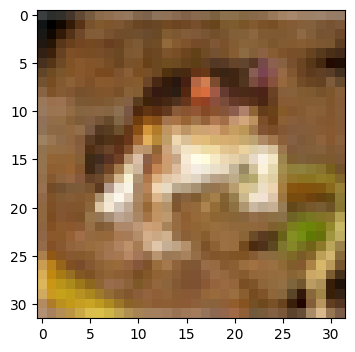

In [5]:
plt.figure(figsize=(4, 4))
plt.imshow(img)
plt.show()

In [6]:
all_data.shape

(50000, 3072)

In [7]:
all_data

array([[ 59,  43,  50, ..., 140,  84,  72],
       [154, 126, 105, ..., 139, 142, 144],
       [255, 253, 253, ...,  83,  83,  84],
       ...,
       [ 35,  40,  42, ...,  77,  66,  50],
       [189, 186, 185, ..., 169, 171, 171],
       [229, 236, 234, ..., 173, 162, 161]], dtype=uint8)

In [8]:
data = pd.DataFrame({
    'image_data': list(all_data),  # Each row will contain 3072 values for image data
    'label': all_labels  # Fine-grained labels
})

In [9]:
data['image_data'] = data['image_data'].apply(
    lambda x: np.array(x).reshape((3, 32, 32)).transpose(1, 2, 0)
)

In [10]:
data.shape

(50000, 2)

In [11]:
data['image_data']

0        [[[59, 62, 63], [43, 46, 45], [50, 48, 43], [6...
1        [[[154, 177, 187], [126, 137, 136], [105, 104,...
2        [[[255, 255, 255], [253, 253, 253], [253, 253,...
3        [[[28, 25, 10], [37, 34, 19], [38, 35, 20], [4...
4        [[[170, 180, 198], [168, 178, 196], [177, 185,...
                               ...                        
49995    [[[145, 161, 194], [151, 166, 199], [156, 171,...
49996    [[[255, 245, 132], [254, 247, 134], [255, 249,...
49997    [[[35, 178, 235], [40, 176, 239], [42, 176, 24...
49998    [[[189, 211, 240], [186, 208, 236], [185, 207,...
49999    [[[229, 229, 239], [236, 237, 247], [234, 236,...
Name: image_data, Length: 50000, dtype: object

In [12]:
data['label'].value_counts()

label
6    5000
9    5000
4    5000
1    5000
2    5000
7    5000
8    5000
3    5000
5    5000
0    5000
Name: count, dtype: int64

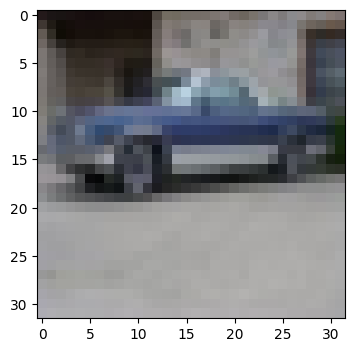

In [13]:
img = data['image_data'][10000]
plt.figure(figsize=(4, 4))
plt.imshow(img)
plt.show()

In [14]:
gpus = tf.config.experimental.list_physical_devices('GPU')
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)

In [15]:
gpus

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

In [16]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, BatchNormalization, Dropout, RandomFlip, RandomRotation
from keras.preprocessing.image import ImageDataGenerator

In [17]:
df = pd.DataFrame(data)

# Define a function for image augmentation
def augment_image(image_array):
    image = tf.convert_to_tensor(image_array, dtype=tf.float32)
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_contrast(image, lower=0.8, upper=1.2)
    return image.numpy()

# Function to create multiple augmented images for each row
def create_augmented_images(image_array, label, num_augments=5):
    augmented_images = []
    for _ in range(num_augments):
        augmented_images.append({"image_data": augment_image(image_array), "label": label})
    return augmented_images

# Generate augmented data for the entire DataFrame
augmented_data = []
for _, row in df.iterrows():
    augmented_data.extend(create_augmented_images(row["image_data"], row["label"], num_augments=2))

# Convert augmented data back to a DataFrame
augmented_df = pd.DataFrame(augmented_data)

# Display the augmented DataFrame
print(augmented_df.head())

                                          image_data  label
0  [[[54.197838, 59.482258, 62.939415], [37.26317...      6
1  [[[149.1824, 127.28892, 109.78005], [153.87846...      6
2  [[[153.5902, 176.19704, 186.0268], [126.0723, ...      9
3  [[[155.19917, 179.34962, 189.84781], [125.7884...      9
4  [[[264.04883, 263.89465, 264.132], [264.04883,...      9


In [18]:
df.shape

(50000, 2)

In [19]:
df.head()

,image_data,label
0,"[[[59, 62, 63], [43, 46, 45], [50, 48, 43], [6...",6
1,"[[[154, 177, 187], [126, 137, 136], [105, 104,...",9
2,"[[[255, 255, 255], [253, 253, 253], [253, 253,...",9
3,"[[[28, 25, 10], [37, 34, 19], [38, 35, 20], [4...",4
4,"[[[170, 180, 198], [168, 178, 196], [177, 185,...",1


In [20]:
merged_df = pd.concat([df, augmented_df], ignore_index=True)

In [21]:
merged_df.head()

,image_data,label
0,"[[[59, 62, 63], [43, 46, 45], [50, 48, 43], [6...",6
1,"[[[154, 177, 187], [126, 137, 136], [105, 104,...",9
2,"[[[255, 255, 255], [253, 253, 253], [253, 253,...",9
3,"[[[28, 25, 10], [37, 34, 19], [38, 35, 20], [4...",4
4,"[[[170, 180, 198], [168, 178, 196], [177, 185,...",1


In [22]:
merged_df.shape

(150000, 2)

In [23]:
model = Sequential([
    Conv2D(96, (2, 2), activation='relu', input_shape=(32, 32, 3)),
    MaxPooling2D(pool_size=(2,2), padding="same"),
    Conv2D(256, (3,3), activation='relu'),
    MaxPooling2D((2,2)),
    Conv2D(381, (3,3), padding="same", activation='relu'),
    Conv2D(384, (3,3), padding="same", activation='relu'),
    Conv2D(256, (3,3), activation='relu'),
    # MaxPooling2D((2,2)),
    Flatten(),
    Dense(400, activation='relu'),
    Dense(400, activation='relu'),
    Dense(10, activation='softmax')
])

In [24]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 31, 31, 96)        1248      
                                                                 
 max_pooling2d (MaxPooling2D  (None, 16, 16, 96)       0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 14, 14, 256)       221440    
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 7, 7, 256)        0         
 2D)                                                             
                                                                 
 conv2d_2 (Conv2D)           (None, 7, 7, 381)         878205    
                                                                 
 conv2d_3 (Conv2D)           (None, 7, 7, 384)         1

In [25]:
model.compile(loss=tf.keras.losses.sparse_categorical_crossentropy,
              optimizer=tf.keras.optimizers.SGD(),
              metrics=[tf.keras.metrics.sparse_categorical_accuracy])

In [26]:
merged_df.head()

,image_data,label
0,"[[[59, 62, 63], [43, 46, 45], [50, 48, 43], [6...",6
1,"[[[154, 177, 187], [126, 137, 136], [105, 104,...",9
2,"[[[255, 255, 255], [253, 253, 253], [253, 253,...",9
3,"[[[28, 25, 10], [37, 34, 19], [38, 35, 20], [4...",4
4,"[[[170, 180, 198], [168, 178, 196], [177, 185,...",1


In [27]:
merged_df['image_data'] = merged_df['image_data'] / 255.0

In [28]:
merged_df['image_data'] = merged_df['image_data'].map(lambda x: (np.round(x, 2)))

In [29]:
merged_df.head()

,image_data,label
0,"[[[0.23, 0.24, 0.25], [0.17, 0.18, 0.18], [0.2...",6
1,"[[[0.6, 0.69, 0.73], [0.49, 0.54, 0.53], [0.41...",9
2,"[[[1.0, 1.0, 1.0], [0.99, 0.99, 0.99], [0.99, ...",9
3,"[[[0.11, 0.1, 0.04], [0.15, 0.13, 0.07], [0.15...",4
4,"[[[0.67, 0.71, 0.78], [0.66, 0.7, 0.77], [0.69...",1


In [30]:
merged_df["label"].value_counts()

label
6    15000
9    15000
4    15000
1    15000
2    15000
7    15000
8    15000
3    15000
5    15000
0    15000
Name: count, dtype: int64

In [31]:
train = merged_df.groupby('label').apply(lambda x: x.sample(13000)).reset_index(drop=True)

In [32]:
images = np.array(train['image_data'].tolist())  # Convert list of 3D arrays to numpy array
labels = np.array(train['label'])  

In [33]:
images.shape

(130000, 32, 32, 3)

In [34]:
labels.shape

(130000,)

In [35]:
valid = merged_df.groupby('label').apply(lambda x: x.sample(2000)).reset_index(drop=True)

In [36]:
valid = valid.sample(frac=1)

In [37]:
images_valid = np.array(valid['image_data'].tolist())
labels_valid = np.array(valid['label'])

In [38]:
model_checkpoint = ModelCheckpoint('AlexNet.h5', save_best_only=True, monitor="val_loss")

In [ ]:
training = model.fit(images, labels, epochs=20, validation_data=(images_valid, labels_valid), callbacks=[model_checkpoint])

Epoch 1/50
4063/4063 [==============================] - 37s 7ms/step - loss: 1.7648 - sparse_categorical_accuracy: 0.3565 - val_loss: 1.7223 - val_sparse_categorical_accuracy: 0.4043
Epoch 2/50
4063/4063 [==============================] - 26s 7ms/step - loss: 1.2453 - sparse_categorical_accuracy: 0.5552 - val_loss: 1.0877 - val_sparse_categorical_accuracy: 0.6152
Epoch 3/50
4063/4063 [==============================] - 27s 7ms/step - loss: 0.9745 - sparse_categorical_accuracy: 0.6568 - val_loss: 0.8943 - val_sparse_categorical_accuracy: 0.6794
Epoch 4/50
4063/4063 [==============================] - 29s 7ms/step - loss: 0.7795 - sparse_categorical_accuracy: 0.7259 - val_loss: 0.6947 - val_sparse_categorical_accuracy: 0.7514
Epoch 5/50
4063/4063 [==============================] - 27s 7ms/step - loss: 0.6288 - sparse_categorical_accuracy: 0.7803 - val_loss: 0.5371 - val_sparse_categorical_accuracy: 0.8129
Epoch 6/50
4063/4063 [==============================] - 27s 7ms/step - loss: 0.5060 -

KeyboardInterrupt: 

In [40]:
import pickle

# Path to the CIFAR-100 train file
file_path = r'.\Dataset\cifar-10-batches-py\test_batch'

# Load the data using pickle with the correct encoding
with open(file_path, 'rb') as f:
    test_dict = pickle.load(f, encoding='latin1')

# The data_dict will contain the images and their corresponding labels
print(test_dict.keys())  # This will show the keys in the dictionary (like 'data', 'labels', etc.)

dict_keys(['batch_label', 'labels', 'data', 'filenames'])


In [41]:
test = pd.DataFrame({
    'image_data': list(test_dict['data']),  # Each row will contain 3072 values for image data
    'label': test_dict['labels']  # Fine-grained labels
})

In [42]:
test.head()

,image_data,label
0,"[158, 159, 165, 166, 160, 156, 162, 159, 158, ...",3
1,"[235, 231, 232, 232, 232, 232, 232, 232, 232, ...",8
2,"[158, 158, 139, 132, 166, 182, 187, 193, 199, ...",8
3,"[155, 167, 176, 190, 177, 166, 168, 166, 170, ...",0
4,"[65, 70, 48, 30, 23, 40, 44, 45, 45, 40, 10, 1...",6


In [43]:
test['image_data'] = test['image_data'].apply(
    lambda x: np.array(x).reshape((3, 32, 32)).transpose(1, 2, 0)
)

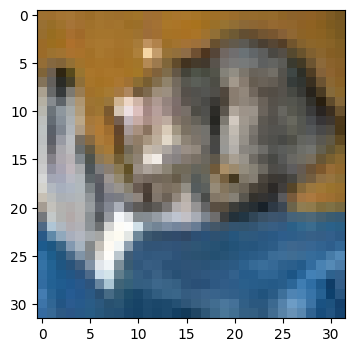

In [44]:
plt.figure(figsize=(4, 4))
plt.imshow(test['image_data'][0])
plt.show()

In [45]:
test.head()

,image_data,label
0,"[[[158, 112, 49], [159, 111, 47], [165, 116, 5...",3
1,"[[[235, 235, 235], [231, 231, 231], [232, 232,...",8
2,"[[[158, 190, 222], [158, 187, 218], [139, 166,...",8
3,"[[[155, 156, 149], [167, 176, 187], [176, 179,...",0
4,"[[[65, 68, 50], [70, 81, 64], [48, 64, 46], [3...",6


In [46]:
test['image_data'] = test['image_data'] / 255.0

In [47]:
test['image_data'] = test['image_data'].map(lambda x: (np.round(x, 2)))

In [48]:
test_images = np.array(test['image_data'].tolist())  # Convert list of 3D arrays to numpy array
test_labels = np.array(test['label'])  

In [49]:
model.evaluate(test_images, test_labels)

313/313 [==============================] - 1s 4ms/step - loss: 1.6422 - sparse_categorical_accuracy: 0.7995


[1.6422338485717773, 0.7994999885559082]

In [50]:
test_pred = model.predict(test_images)

In [51]:
test_pred[0]

array([1.5212605e-08, 4.4827033e-07, 4.5318253e-11, 9.9999905e-01,
       2.3646837e-15, 4.4395802e-07, 6.8164696e-10, 9.6717285e-13,
       1.1989002e-12, 1.4884131e-10], dtype=float32)

In [52]:
test_pred = test_pred.argmax(axis=-1)

In [53]:
f1_class = f1_score(test_labels, test_pred,average=None)
print(f1_class)

[0.82226562 0.88699146 0.73673573 0.62378765 0.77644711 0.69872424
 0.85728593 0.85240964 0.88451841 0.8541563 ]


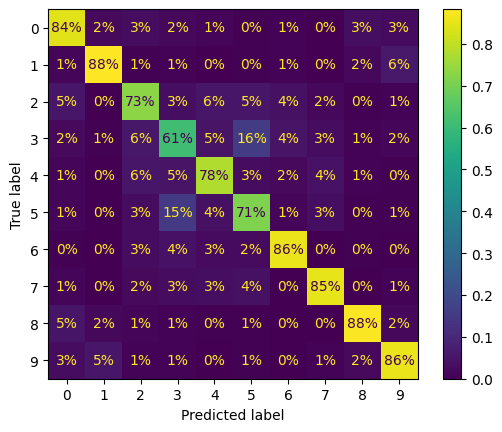

In [54]:
ConfusionMatrixDisplay.from_predictions(test_labels, test_pred, normalize='true', values_format='.0%')

In [55]:
model.save(os.path.join('models','cifer_classifier_CNN3.h5'))